In [ ]:
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.metrics import make_scorer
from xgboost import XGBClassifier
!pip install catboost
from catboost import CatBoostClassifier

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("lithium-ion batteries.csv")

# -----------------------------
# Parse formula into element counts
# -----------------------------
def parse_formula_counts(formula):
    tokens = re.findall(r'([A-Z][a-z]?)(\d*)', str(formula))
    counts = {}
    for el, num in tokens:
        counts[el] = counts.get(el, 0) + (int(num) if num else 1)
    return counts

elements = ["Li", "Co", "Fe", "Mn", "Si", "O"]

for el in elements:
    df[el] = df["Formula"].apply(lambda x: parse_formula_counts(x).get(el, 0))

df["TM_total"] = df[["Co", "Fe", "Mn"]].sum(axis=1)
df["Li_to_Si"] = df["Li"] / df["Si"].replace(0, np.nan)
df["TM_to_Si"] = df["TM_total"] / df["Si"].replace(0, np.nan)
df["O_to_Si"] = df["O"] / df["Si"].replace(0, np.nan)
df["Li_to_TM"] = df["Li"] / df["TM_total"].replace(0, np.nan)

# -----------------------------
# Target
# -----------------------------
y = df["Crystal System"]
y = LabelEncoder().fit_transform(y) # Add this line to encode target variable

# -----------------------------
# Features
# Keep Formula-derived features, but remove Spacegroup
# -----------------------------
feature_cols = [
    "Formation Energy (eV)",
    "E Above Hull (eV)",
    "Band Gap (eV)",
    "Nsites",
    "Density (gm/cc)",
    "Volume",
    "Has Bandstructure",
    "Li", "Co", "Fe", "Mn", "Si", "O",
    "TM_total", "Li_to_Si", "TM_to_Si", "O_to_Si", "Li_to_TM"
]

X = df[feature_cols].copy()

X["Has Bandstructure"] = X["Has Bandstructure"].replace({
    "TRUE": 1, "FALSE": 0, True: 1, False: 0
}).astype(float)

# -----------------------------
# Models
# -----------------------------
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=10,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="mlogloss",
        random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="MultiClass",
        verbose=False,
        random_state=42
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=400,
        max_depth=10,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )
}

# -----------------------------
# CV
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro",
    "roc_auc": "roc_auc_ovr"
}

rows = []

for name, model in models.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=1)

    rows.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC_AUC": scores["test_roc_auc"].mean()
    })

results = pd.DataFrame(rows).sort_values("Accuracy", ascending=False)
print(results.round(4))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00


/tmp/ipykernel_8060/2698912934.py:66: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X["Has Bandstructure"] = X["Has Bandstructure"].replace({


               Model  Accuracy  Precision  Recall      F1  ROC_AUC
2            XGBoost    0.6724     0.7018  0.6559  0.6653   0.8292
4        Extra Trees    0.6666     0.6615  0.6651  0.6578   0.8136
0      Random Forest    0.6576     0.6698  0.6606  0.6600   0.8281
1  Gradient Boosting    0.6546     0.6723  0.6386  0.6397   0.8175
3           CatBoost    0.6457     0.6658  0.6344  0.6396   0.8217
5           AdaBoost    0.5454     0.6048  0.5253  0.5336   0.7340


In [ ]:
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.metrics import make_scorer
from xgboost import XGBClassifier
!pip install catboost
from catboost import CatBoostClassifier

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("lithium-ion batteries.csv")

import re
import numpy as np
import pandas as pd

# -----------------------------
# Parse chemical formula
# -----------------------------
def parse_formula_counts(formula):
    tokens = re.findall(r'([A-Z][a-z]?)(\d*)', str(formula))
    counts = {}
    for el, num in tokens:
        counts[el] = counts.get(el, 0) + (int(num) if num else 1)
    return counts

all_counts = df["Formula"].apply(parse_formula_counts)

# -----------------------------
# Build full element vocabulary
# -----------------------------
element_vocab = sorted(set().union(*all_counts))

for el in element_vocab:
    df[f"el_{el}"] = all_counts.apply(lambda x: x.get(el, 0))

# -----------------------------
# Chemistry groups
# -----------------------------
transition_metals = {"Sc","Ti","V","Cr","Mn","Fe","Co","Ni","Cu","Zn"}
alkali_metals = {"Li","Na","K","Rb","Cs"}
non_metals = {"H","C","N","O","F","P","S","Cl","Se","Br","I"}

# -----------------------------
# Formula statistics
# -----------------------------
def formula_stats(counts):
    vals = np.array(list(counts.values()), dtype=float)
    total_atoms = vals.sum() if len(vals) else 0

    return pd.Series({
        "num_unique_elements": len(counts),
        "total_atoms": total_atoms,
        "max_stoich": vals.max() if len(vals) else 0,
        "min_stoich": vals.min() if len(vals) else 0,
        "mean_stoich": vals.mean() if len(vals) else 0,
        "std_stoich": vals.std() if len(vals) else 0,

        "tm_count": sum(counts.get(e, 0) for e in transition_metals),
        "alkali_count": sum(counts.get(e, 0) for e in alkali_metals),
        "nonmetal_count": sum(counts.get(e, 0) for e in non_metals),

        "frac_Li": counts.get("Li", 0) / total_atoms if total_atoms else 0,
        "frac_O": counts.get("O", 0) / total_atoms if total_atoms else 0,
        "frac_P": counts.get("P", 0) / total_atoms if total_atoms else 0,
        "frac_F": counts.get("F", 0) / total_atoms if total_atoms else 0,

        "has_Li": int("Li" in counts),
        "has_O": int("O" in counts),
        "has_P": int("P" in counts),
        "has_F": int("F" in counts),
        "has_Ni": int("Ni" in counts),
        "has_Co": int("Co" in counts),
        "has_Mn": int("Mn" in counts),
        "has_Fe": int("Fe" in counts),
        "has_Ti": int("Ti" in counts),
        "has_V": int("V" in counts),
        "has_Si": int("Si" in counts),
    })

formula_df = all_counts.apply(formula_stats)
df = pd.concat([df, formula_df], axis=1)

# -----------------------------
# High-value ratios
# -----------------------------
df["Li_to_tm"] = df["el_Li"] / df["tm_count"].replace(0, np.nan)
df["O_to_tm"] = df["el_O"] / df["tm_count"].replace(0, np.nan)
df["Li_to_O"] = df["el_Li"] / df["el_O"].replace(0, np.nan)
df["tm_to_total"] = df["tm_count"] / df["total_atoms"].replace(0, np.nan)

# -----------------------------
# Target
# -----------------------------
y = df["Crystal System"]
y = LabelEncoder().fit_transform(y) # Add this line to encode target variable

# -----------------------------
# Features
# Keep Formula-derived features, but remove Spacegroup
# -----------------------------
feature_cols = [
    "Formation Energy (eV)",
    "E Above Hull (eV)",
    "Band Gap (eV)",
    "Nsites",
    "Density (gm/cc)",
    "Volume",
    "Has Bandstructure",
    "el_Li", "el_Co", "el_Fe", "el_Mn", "el_Si", "el_O", # Updated element counts
    "tm_count", "Li_to_tm", "O_to_tm", "Li_to_O", "tm_to_total", # New TM count and ratios
    "num_unique_elements", "total_atoms", "max_stoich", "min_stoich", "mean_stoich", "std_stoich",
    "alkali_count", "nonmetal_count", "frac_Li", "frac_O", "frac_P", "frac_F",
    "has_Li", "has_O", "has_P", "has_F", "has_Ni", "has_Co", "has_Mn", "has_Fe", "has_Ti", "has_V", "has_Si"
]

X = df[feature_cols].copy()

X["Has Bandstructure"] = X["Has Bandstructure"].replace({
    "TRUE": 1, "FALSE": 0, True: 1, False: 0
}).astype(float)

# -----------------------------
# Models
# -----------------------------
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=10,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="mlogloss",
        random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="MultiClass",
        verbose=False,
        random_state=42
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=400,
        max_depth=10,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )
}

# -----------------------------
# CV
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro",
    "roc_auc": "roc_auc_ovr"
}

rows = []

for name, model in models.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=1)

    rows.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC_AUC": scores["test_roc_auc"].mean()
    })

results = pd.DataFrame(rows).sort_values("Accuracy", ascending=False)
print(results.round(4))

/tmp/ipykernel_8060/1763836069.py:127: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X["Has Bandstructure"] = X["Has Bandstructure"].replace({


               Model  Accuracy  Precision  Recall      F1  ROC_AUC
2            XGBoost    0.6812     0.7059  0.6700  0.6776   0.8360
1  Gradient Boosting    0.6694     0.6926  0.6540  0.6636   0.8411
3           CatBoost    0.6517     0.6807  0.6480  0.6564   0.8275
0      Random Forest    0.6459     0.6604  0.6484  0.6460   0.8178
4        Extra Trees    0.6313     0.6280  0.6328  0.6239   0.7939
5           AdaBoost    0.5160     0.5598  0.5039  0.5092   0.7310


/tmp/ipykernel_8060/649975501.py:142: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X["Has Bandstructure"] = X["Has Bandstructure"].replace({



Final Complete Results
Accuracy : 0.6737
Precision: 0.6967
Recall   : 0.6729
F1       : 0.6779
ROC_AUC  : 0.8322

Per Fold Results
    Accuracy  Precision  Recall      F1  ROC_AUC
0     0.6618     0.6861  0.6703  0.6770   0.8281
1     0.7500     0.7834  0.7125  0.7257   0.8223
2     0.6912     0.7262  0.6870  0.7016   0.8554
3     0.6765     0.6850  0.6737  0.6781   0.8527
4     0.5970     0.6202  0.5688  0.5758   0.7796
5     0.6912     0.7338  0.7079  0.7184   0.8416
6     0.6471     0.6744  0.6566  0.6598   0.8129
7     0.7206     0.7443  0.7225  0.7318   0.8345
8     0.6912     0.7117  0.6617  0.6721   0.8430
9     0.6418     0.6664  0.6522  0.6560   0.8466
10    0.7059     0.6927  0.6960  0.6924   0.8584
11    0.6176     0.6531  0.6145  0.6222   0.7749
12    0.6471     0.6583  0.6527  0.6534   0.7856
13    0.6765     0.6822  0.6779  0.6788   0.8457
14    0.6567     0.6679  0.6888  0.6769   0.8271
15    0.6618     0.6689  0.6694  0.6668   0.8241
16    0.6324     0.6714  0.6337  0.

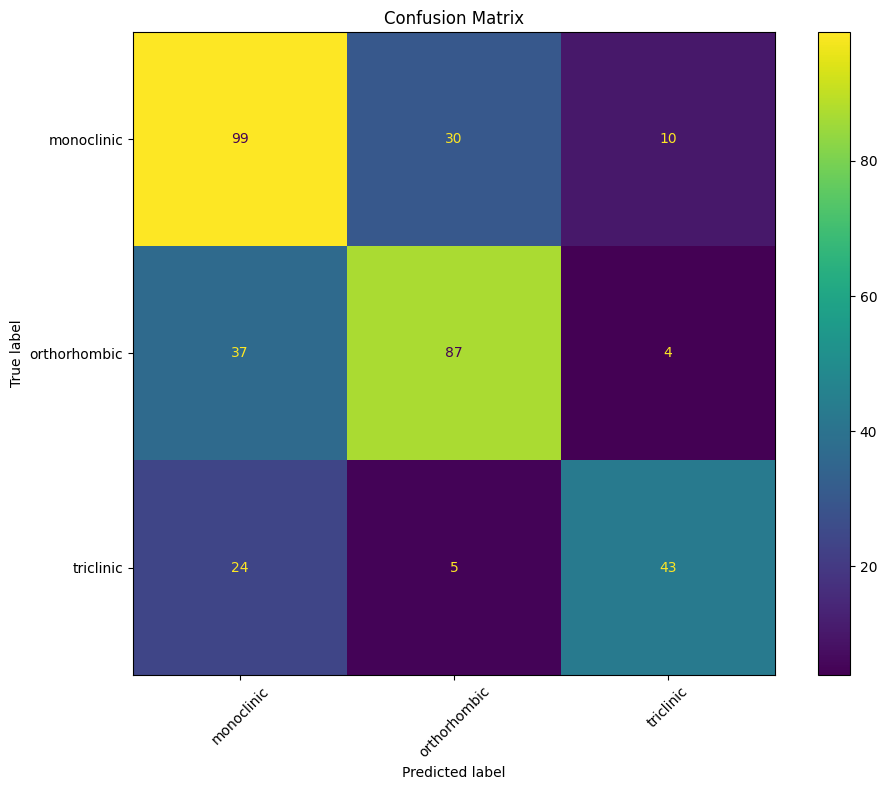


Top 20 Important Features
                  Feature  Importance
19               tm_count    0.145216
12                  el_Si    0.117600
14            total_atoms    0.086717
17            mean_stoich    0.081739
20           alkali_count    0.046587
18             std_stoich    0.042637
15             max_stoich    0.039704
3                  Nsites    0.035088
16             min_stoich    0.035038
22                frac_Li    0.031995
9                   el_Li    0.031899
5                  Volume    0.030936
23                 frac_O    0.030863
6       Has Bandstructure    0.030640
27                O_to_tm    0.028604
28            tm_to_total    0.026117
11                   el_O    0.024179
26               Li_to_tm    0.020540
0   Formation Energy (eV)    0.019251
4         Density (gm/cc)    0.017391


In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os # Import os module

from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    RandomizedSearchCV,
    cross_validate,
    cross_val_predict,
    StratifiedKFold
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

# -----------------------------
# Load data
# -----------------------------
file_path = "lithium-ion batteries.csv"

# Check if the file exists, if not, instruct the user to upload it
if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found.")
    print("Please upload the file to your Colab environment or ensure it's in the correct directory.")
    # Uncomment the following lines if you want to use the Colab file upload widget
    # from google.colab import files
    # uploaded = files.upload()
    raise FileNotFoundError(f"Missing data file: {file_path}")

df = pd.read_csv(file_path)

# -----------------------------
# Parse chemical formula
# -----------------------------
def parse_formula_counts(formula):
    tokens = re.findall(r'([A-Z][a-z]?)(\d*)', str(formula)) # Corrected regex: added capturing group for numbers
    counts = {}
    for el, num in tokens:
        counts[el] = counts.get(el, 0) + (int(num) if num else 1)
    return counts

all_counts = df["Formula"].apply(parse_formula_counts)

# -----------------------------
# Full element vocabulary
# -----------------------------
element_vocab = sorted(set().union(*all_counts))

for el in element_vocab:
    df[f"el_{el}"] = all_counts.apply(lambda x: x.get(el, 0))

# -----------------------------
# Chemistry groups
# -----------------------------
transition_metals = {"Sc","Ti","V","Cr","Mn","Fe","Co","Ni","Cu","Zn"}
alkali_metals = {"Li","Na","K","Rb","Cs"}
non_metals = {"H","C","N","O","F","P","S","Cl","Se","Br","I"}

# -----------------------------
# Formula statistics
# -----------------------------
def formula_stats(counts):
    vals = np.array(list(counts.values()), dtype=float)
    total_atoms = vals.sum() if len(vals) else 0

    return pd.Series({
        "num_unique_elements": len(counts),
        "total_atoms": total_atoms,
        "max_stoich": vals.max() if len(vals) else 0,
        "min_stoich": vals.min() if len(vals) else 0,
        "mean_stoich": vals.mean() if len(vals) else 0,
        "std_stoich": vals.std() if len(vals) else 0,
        "tm_count": sum(counts.get(e, 0) for e in transition_metals),
        "alkali_count": sum(counts.get(e, 0) for e in alkali_metals),
        "nonmetal_count": sum(counts.get(e, 0) for e in non_metals),
        "frac_Li": counts.get("Li", 0) / total_atoms if total_atoms else 0,
        "frac_O": counts.get("O", 0) / total_atoms if total_atoms else 0,
        "frac_P": counts.get("P", 0) / total_atoms if total_atoms else 0,
        "frac_F": counts.get("F", 0) / total_atoms if total_atoms else 0
    })

formula_df = all_counts.apply(formula_stats)
df = pd.concat([df, formula_df], axis=1)

# -----------------------------
# Ratio features
# -----------------------------
df["Li_to_tm"] = df.get("el_Li", 0) / df["tm_count"].replace(0, np.nan)
df["O_to_tm"] = df.get("el_O", 0) / df["tm_count"].replace(0, np.nan)
df["tm_to_total"] = df["tm_count"] / df["total_atoms"].replace(0, np.nan)
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# -----------------------------
# Target
# -----------------------------
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["Crystal System"])

# -----------------------------
# Features
# -----------------------------
base_features = [
    "Formation Energy (eV)",
    "E Above Hull (eV)",
    "Band Gap (eV)",
    "Nsites",
    "Density (gm/cc)",
    "Volume",
    "Has Bandstructure"
]

formula_features = [c for c in df.columns if c.startswith("el_")] + [
    "num_unique_elements",
    "total_atoms",
    "max_stoich",
    "min_stoich",
    "mean_stoich",
    "std_stoich",
    "tm_count",
    "alkali_count",
    "nonmetal_count",
    "frac_Li",
    "frac_O",
    "frac_P",
    "frac_F",
    "Li_to_tm",
    "O_to_tm",
    "tm_to_total"
]

feature_cols = [c for c in base_features + formula_features if c in df.columns]
X = df[feature_cols].copy()

X["Has Bandstructure"] = X["Has Bandstructure"].replace({
    "TRUE": 1, "FALSE": 0, True: 1, False: 0
}).astype(float)

# -----------------------------
# Pipeline
# -----------------------------
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        objective="multi:softprob",
        n_estimators=700,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.2,
        reg_lambda=1.5,
        eval_metric="mlogloss",
        random_state=42
    ))
])

# -----------------------------
# CV setup for cross_validate
# -----------------------------
cv_repeated = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)

# CV setup for cross_val_predict (requires a single partition)
cv_single_split = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro",
    "roc_auc": "roc_auc_ovr"
}

# -----------------------------
# Cross-validation scores
# -----------------------------
scores = cross_validate(
    pipe,
    X,
    y,
    cv=cv_repeated,
    scoring=scoring,
    n_jobs=-1,
    return_estimator=True
)

print("\nFinal Complete Results")
print("Accuracy :", round(scores["test_accuracy"].mean(), 4))
print("Precision:", round(scores["test_precision"].mean(), 4))
print("Recall   :", round(scores["test_recall"].mean(), 4))
print("F1       :", round(scores["test_f1"].mean(), 4))
print("ROC_AUC  :", round(scores["test_roc_auc"].mean(), 4))

# -----------------------------
# Per-fold table
# -----------------------------
fold_results = pd.DataFrame({
    "Accuracy": scores["test_accuracy"],
    "Precision": scores["test_precision"],
    "Recall": scores["test_recall"],
    "F1": scores["test_f1"],
    "ROC_AUC": scores["test_roc_auc"]
})
print("\nPer Fold Results")
print(fold_results.round(4))

# -----------------------------
# Predictions for report
# -----------------------------
y_pred = cross_val_predict(pipe, X, y, cv=cv_single_split, n_jobs=-1)

print("\nClassification Report")
print(classification_report(y, y_pred, target_names=label_encoder.classes_))

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# -----------------------------
# Feature importance
# -----------------------------
pipe.fit(X, y)
model = pipe.named_steps["model"]

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTop 20 Important Features")
print(importance.head(20))

### Feature Correlation Diagram

Below is a heatmap illustrating the correlation matrix of the features used in the model. This helps in understanding the relationships between different features.

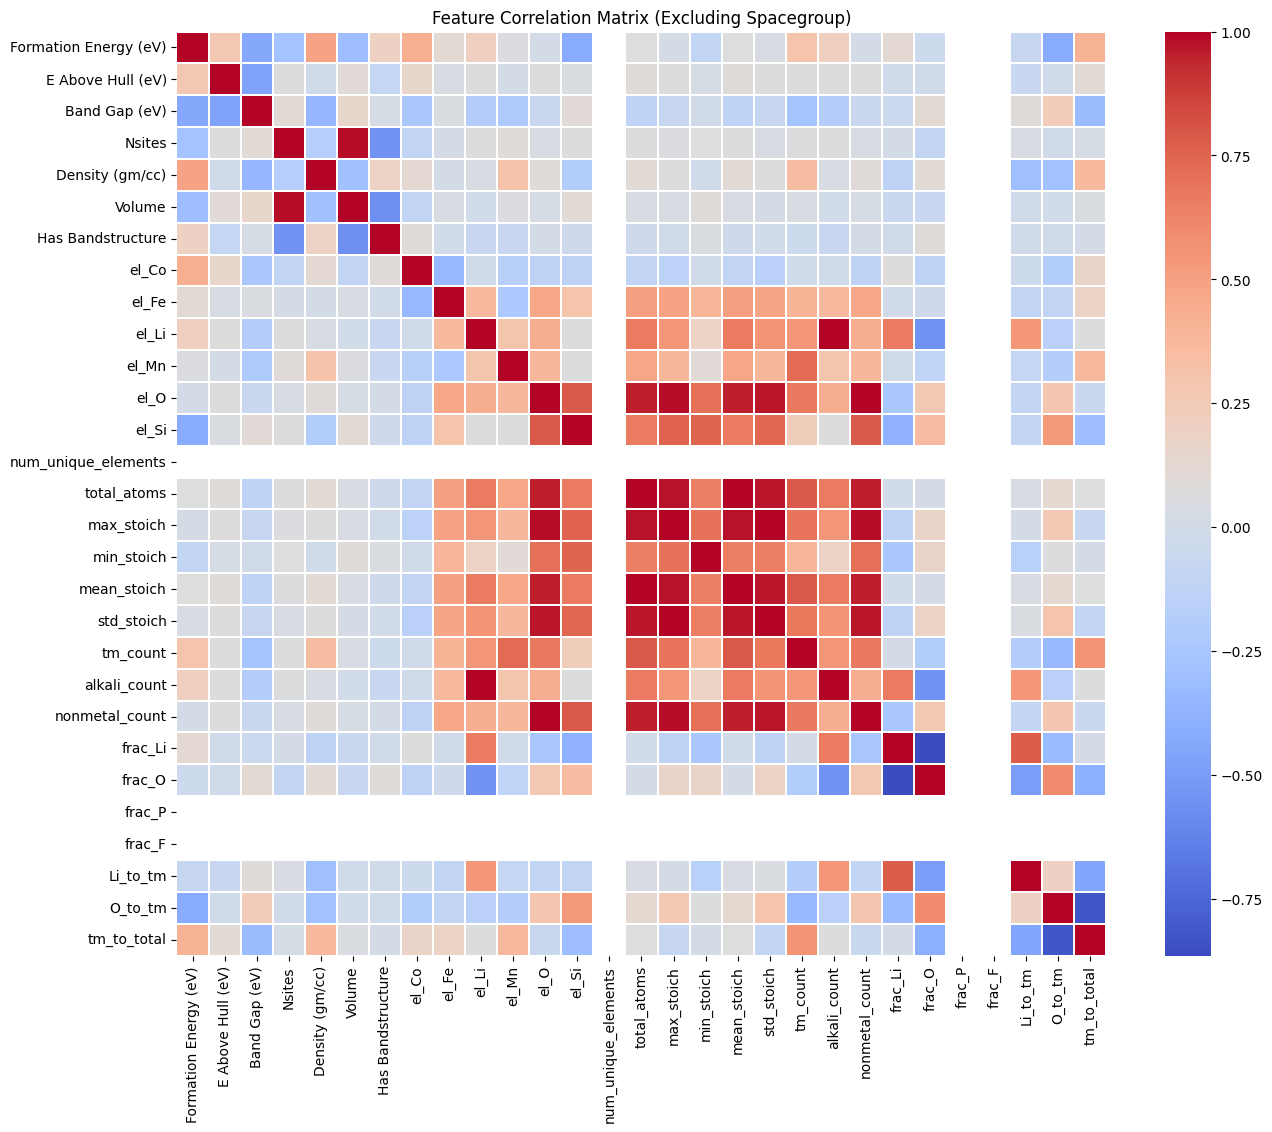

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 12))
sns.heatmap(X.corr(), annot=False, cmap='coolwarm', fmt=".2f", linewidths=.05)
plt.title('Feature Correlation Matrix (Excluding Spacegroup)')
plt.show()

### Correlation between Top 10 Important Features and Target

This heatmap visualizes the correlation matrix between the top 10 features identified as most important by the model and the target variable ('Crystal System'). This helps to understand how strongly these key features relate to each other and to the outcome we are trying to predict.

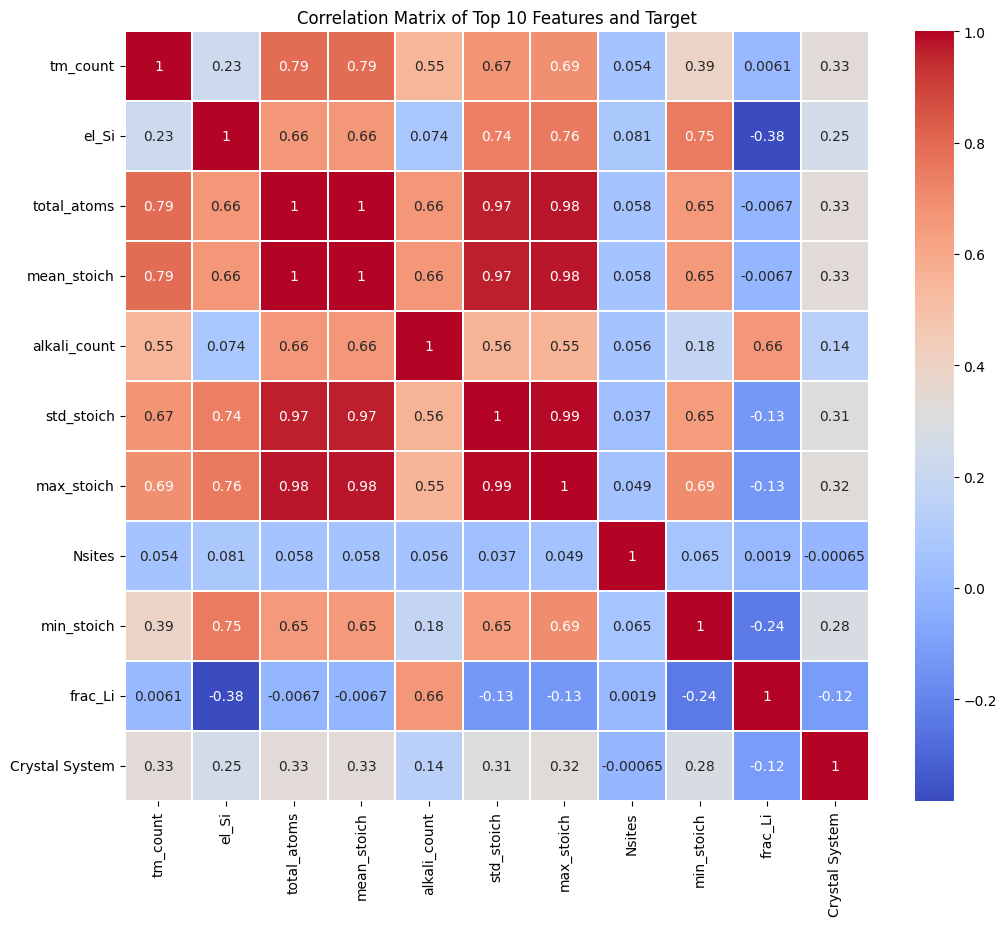

In [ ]:
top_10_features = importance.head(10)["Feature"].tolist()

# Create a DataFrame with the top 10 features and the target variable
X_top_features_and_target = X[top_10_features].copy()
X_top_features_and_target['Crystal System'] = y

plt.figure(figsize=(12, 10)) # Adjust figure size for more features
sns.heatmap(X_top_features_and_target.corr(), annot=True, cmap='coolwarm', linewidths=.05)
plt.title('Correlation Matrix of Top 10 Features and Target')
plt.show()